<a href="https://colab.research.google.com/github/haqiaryva/UTS-DeepLearning/blob/main/Studi_Kasus_2_HOG_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory
import matplotlib.pyplot as plt
import cv2
from numpy.linalg import norm
import datetime
from sklearn import svm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import cross_val_score

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sub = pd.read_csv('sample_submission.csv')

EDA

In [ ]:
print(f"Training data size is {train.shape}\nTesting data size is {test.shape}")

Training data size is (16061, 785)
Testing data size is (17806, 784)


In [ ]:
X = train.drop(['label'], axis=1).values
y = train['label'].values

In [ ]:
X = X / 255.0

In [ ]:
X = X.reshape(-1,28,28,1)

In [ ]:
y = to_categorical(y)

print(f"Label size {y.shape}")

Label size (16061, 10)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((14454, 28, 28, 1), (1607, 28, 28, 1), (14454, 10), (1607, 10))

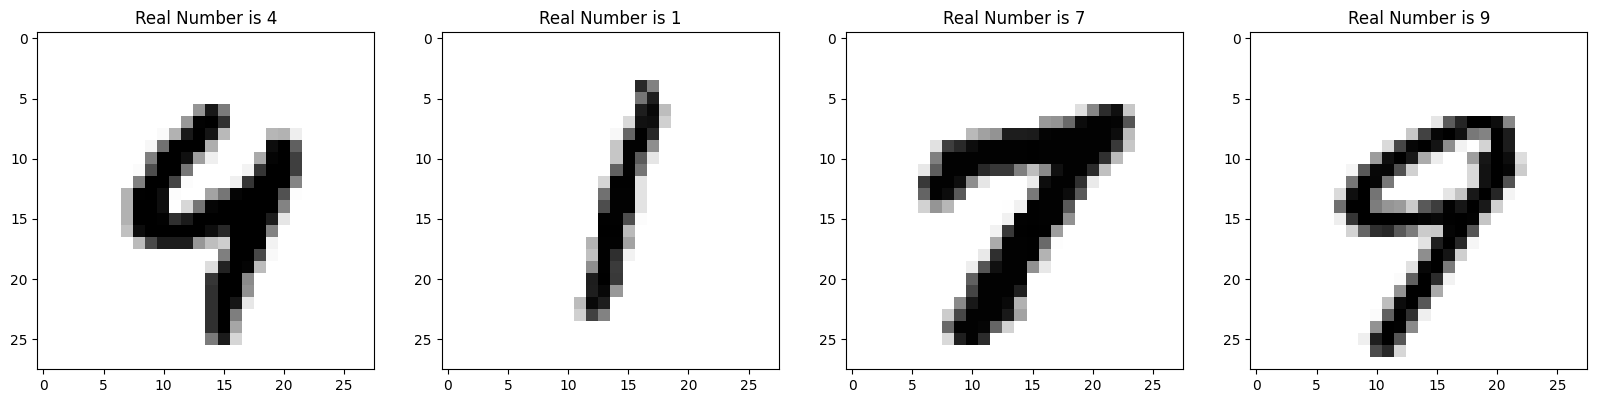

In [ ]:
X_train__ = X_train.reshape(X_train.shape[0], 28, 28)

fig, axis = plt.subplots(1, 4, figsize=(20, 10))
for i, ax in enumerate(axis.flat):
    ax.imshow(X_train__[i], cmap='binary')
    digit = y_train[i].argmax()
    ax.set(title = f"Real Number is {digit}");

In [ ]:
mean = np.mean(X_train)
std = np.std(X_train)

def standardize(x):
    return (x-mean)/std

In [ ]:
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier

def extract_hog_features(data):
    hog_features = []
    for img in data:
        # Reshape kembali ke 28x28 karena HOG memerlukan input 2D
        img_2d = img.reshape(28, 28)
        # Ekstraksi fitur HOG
        fd = hog(img_2d, orientations=9, pixels_per_cell=(7, 7),
                 cells_per_block=(2, 2), visualize=False)
        hog_features.append(fd)
    return np.array(hog_features)

print("Mengekstrak fitur HOG untuk data training...")
X_train_hog = extract_hog_features(X_train)
print("Mengekstrak fitur HOG untuk data testing...")
X_test_hog = extract_hog_features(X_test)

print(f"Ukuran fitur HOG training: {X_train_hog.shape}")

Mengekstrak fitur HOG untuk data training...
Mengekstrak fitur HOG untuk data testing...
Ukuran fitur HOG training: (14454, 324)


In [ ]:
# Karena Random Forest di sklearn tidak mendukung multi-label output secara langsung
# dari to_categorical (one-hot), kita gunakan label asli (integer)
y_train_labels = y_train.argmax(axis=1)
y_test_labels = y_test.argmax(axis=1)

# Inisialisasi dan latih Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_hog, y_train_labels)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


Akurasi Model RF + HOG: 96.45%


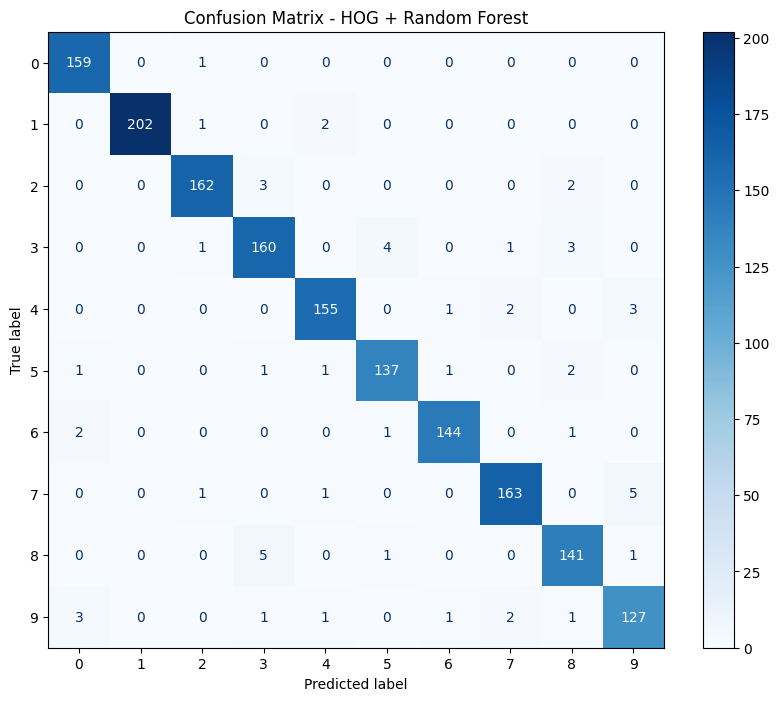

In [ ]:
# Prediksi dan Evaluasi
y_pred = rf_model.predict(X_test_hog)
accuracy = accuracy_score(y_test_labels, y_pred)

print(f"Akurasi Model RF + HOG: {accuracy * 100:.2f}%")

# Menampilkan Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test_labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - HOG + Random Forest')
plt.show()